# Calendar Spread Strategy: TMC Earnings (2025-11-13)

This notebook demonstrates a **calendar spread** (time spread) strategy for TMC's earnings on November 13, 2025.

## What is a Calendar Spread?

- **Sell** near-term option (short leg) 
- **Buy** longer-term option (long leg)
- Same strike, same option type

## Why for Earnings?

1. **IV Crush**: Short-term options lose more IV after earnings
2. **Theta Decay**: Short-term decays faster
3. **Defined Risk**: Max loss = net debit paid
4. **Delta-Neutral**: Minimal directional exposure

## TMC Setup

- Earnings: Nov 13, 2025
- Short Leg: Nov 21, 2025 (8 DTE)
- Long Leg: Nov 28, 2025 (15 DTE)
- Strike: $5.00 (ATM)

In [5]:
import sys
sys.path.insert(0, '../src')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime

from dlt_ibapi.repositories import (
    EquityBarsReader,
    OptionBarsReader, 
    EarningsCalendarReader
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
con = duckdb.connect()

print("✅ Setup complete")

✅ Setup complete


## 1. Load Market Data

In [6]:
# Load TMC spot prices using EquityBarsReader
equity_reader = EquityBarsReader(database_path='../data_delta', dataset_name='stocks')

spot_prices = equity_reader.get_bars(
    symbol='TMC',
    bar_size='1 day',
    start_date=date(2025, 11, 1),
    end_date=date(2025, 11, 15)
)

print("TMC Spot Prices:")
print(spot_prices[['date', 'close']])

# Params
earnings_date = '2025-11-13'
spot_on_earnings = spot_prices[spot_prices['date'] == earnings_date]['close'].iloc[0]
print(f"\nSpot on earnings: ${spot_on_earnings:.2f}")

TMC Spot Prices:
         date  close
0  2025-11-03  6.395
1  2025-11-04  5.990
2  2025-11-05  6.000
3  2025-11-06  5.530
4  2025-11-07  5.730
5  2025-11-10  5.910
6  2025-11-11  5.830
7  2025-11-12  5.640
8  2025-11-13  5.170
9  2025-11-14  5.080

Spot on earnings: $5.17


In [7]:
# Config
short_exp = date(2025, 11, 21)  # Use date objects
long_exp = date(2025, 11, 28)
strike = 5.0

# Initialize OptionBarsReader
option_reader = OptionBarsReader(database_path='../data_delta', dataset_name='options')

# Load option data using library's load_option_leg_bars() method
# This already handles datetime parsing and returns clean data with 'datetime' column
short_call_bars = option_reader.load_option_leg_bars(
    underlying='TMC',
    expiry=short_exp,
    strike=strike,
    option_type='C',
    bar_size='1 hour'
)

long_call_bars = option_reader.load_option_leg_bars(
    underlying='TMC',
    expiry=long_exp,
    strike=strike,
    option_type='C',
    bar_size='1 hour'
)

short_put_bars = option_reader.load_option_leg_bars(
    underlying='TMC',
    expiry=short_exp,
    strike=strike,
    option_type='P',
    bar_size='1 hour'
)

long_put_bars = option_reader.load_option_leg_bars(
    underlying='TMC',
    expiry=long_exp,
    strike=strike,
    option_type='P',
    bar_size='1 hour'
)

print(f"Data loaded (intraday bars):")
print(f"  Short Call ({short_exp}): {len(short_call_bars) if short_call_bars is not None else 0} bars")
print(f"  Long Call ({long_exp}): {len(long_call_bars) if long_call_bars is not None else 0} bars")
print(f"  Short Put ({short_exp}): {len(short_put_bars) if short_put_bars is not None else 0} bars")
print(f"  Long Put ({long_exp}): {len(long_put_bars) if long_put_bars is not None else 0} bars")

Data loaded (intraday bars):
  Short Call (2025-11-21): 126 bars
  Long Call (2025-11-28): 50 bars
  Short Put (2025-11-21): 140 bars
  Long Put (2025-11-28): 68 bars


## 2. Construct Calendar Spread

In [8]:
from dlt_ibapi.strategies import get_option_price_at_time

# Entry datetime (3pm day before earnings)
entry_dt = datetime(2025, 11, 12, 15, 0, 0)

# Get entry prices using library function
short_call_entry = get_option_price_at_time(short_call_bars, entry_dt)
long_call_entry = get_option_price_at_time(long_call_bars, entry_dt)
short_put_entry = get_option_price_at_time(short_put_bars, entry_dt)
long_put_entry = get_option_price_at_time(long_put_bars, entry_dt)

# Calculate spreads
call_spread_cost = long_call_entry - short_call_entry
put_spread_cost = long_put_entry - short_put_entry

print("="*70)
print(f"CALENDAR SPREAD SETUP (Entry: {entry_dt.date()})")
print("="*70)
print(f"\nCALL CALENDAR (${strike} strike):")
print(f"  Sell {short_exp}: ${short_call_entry:.3f}")
print(f"  Buy  {long_exp}:  ${long_call_entry:.3f}")
print(f"  Net Debit:       ${call_spread_cost:.3f}")
print(f"  Cost/Contract:   ${call_spread_cost * 100:.2f}")

print(f"\nPUT CALENDAR (${strike} strike):")
print(f"  Sell {short_exp}: ${short_put_entry:.3f}")
print(f"  Buy  {long_exp}:  ${long_put_entry:.3f}")
print(f"  Net Debit:       ${put_spread_cost:.3f}")
print(f"  Cost/Contract:   ${put_spread_cost * 100:.2f}")

CALENDAR SPREAD SETUP (Entry: 2025-11-12)

CALL CALENDAR ($5.0 strike):
  Sell 2025-11-21: $0.900
  Buy  2025-11-28:  $1.050
  Net Debit:       $0.150
  Cost/Contract:   $15.00

PUT CALENDAR ($5.0 strike):
  Sell 2025-11-21: $0.200
  Buy  2025-11-28:  $0.200
  Net Debit:       $0.000
  Cost/Contract:   $0.00


In [9]:
short_call_entry

np.float64(0.9)

## 3. Calculate P&L Over Time

In [10]:
def calculate_spread_pnl(short_df, long_df, entry_cost):
    """Calculate calendar spread P&L"""
    # Merge on datetime
    merged = pd.merge(
        short_df.rename(columns={'close': 'short_price'}),
        long_df.rename(columns={'close': 'long_price'}),
        on='datetime',
        how='outer'
    ).sort_values('datetime')
    
    # Forward fill missing prices
    merged['short_price'] = merged['short_price'].fillna(method='ffill')
    merged['long_price'] = merged['long_price'].fillna(method='ffill')
    merged = merged.dropna()
    
    # Calculate spread value and P&L
    merged['spread_value'] = merged['long_price'] - merged['short_price']
    merged['pnl'] = merged['spread_value'] - entry_cost
    merged['pnl_pct'] = (merged['pnl'] / entry_cost) * 100
    merged['pnl_per_contract'] = merged['pnl'] * 100
    
    return merged

call_pnl = calculate_spread_pnl(short_call_bars, long_call_bars, call_spread_cost)
put_pnl = calculate_spread_pnl(short_put_bars, long_put_bars, put_spread_cost)

print("Call Calendar P&L:")
print(call_pnl[['datetime', 'short_price', 'long_price', 'spread_value', 'pnl', 'pnl_pct']].tail())

print("\nPut Calendar P&L:")
print(put_pnl[['datetime', 'short_price', 'long_price', 'spread_value', 'pnl', 'pnl_pct']].tail())

Call Calendar P&L:
               datetime  short_price  long_price  spread_value   pnl  \
155 2025-11-13 14:00:00         0.65         0.6         -0.05 -0.20   
158 2025-11-13 15:00:00         0.60         0.6          0.00 -0.15   
159 2025-11-13 15:00:00         0.60         0.6          0.00 -0.15   
160 2025-11-13 15:00:00         0.60         0.6          0.00 -0.15   
161 2025-11-13 15:00:00         0.60         0.6          0.00 -0.15   

        pnl_pct  
155 -133.333333  
158 -100.000000  
159 -100.000000  
160 -100.000000  
161 -100.000000  

Put Calendar P&L:
               datetime  short_price  long_price  spread_value  pnl  pnl_pct
201 2025-11-14 14:00:00         0.35        0.35           0.0  0.0      NaN
205 2025-11-14 15:00:00         0.25        0.35           0.1  0.1      inf
206 2025-11-14 15:00:00         0.25        0.35           0.1  0.1      inf
204 2025-11-14 15:00:00         0.25        0.35           0.1  0.1      inf
207 2025-11-14 15:00:00         0.25

/var/folders/r7/gpyw0j9j5bxfcmd8ydmr2j1w0000gn/T/ipykernel_91449/3000296062.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['short_price'] = merged['short_price'].fillna(method='ffill')
/var/folders/r7/gpyw0j9j5bxfcmd8ydmr2j1w0000gn/T/ipykernel_91449/3000296062.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['long_price'] = merged['long_price'].fillna(method='ffill')
/var/folders/r7/gpyw0j9j5bxfcmd8ydmr2j1w0000gn/T/ipykernel_91449/3000296062.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['short_price'] = merged['short_price'].fillna(method='ffill')
/var/folders/r7/gpyw0j9j5bxfcmd8ydmr2j1w0000gn/T/ipykernel_91449/3000296062.py:13: FutureWarning: Series.fillna with 'method' is deprecated a

## 4. Visualize Performance

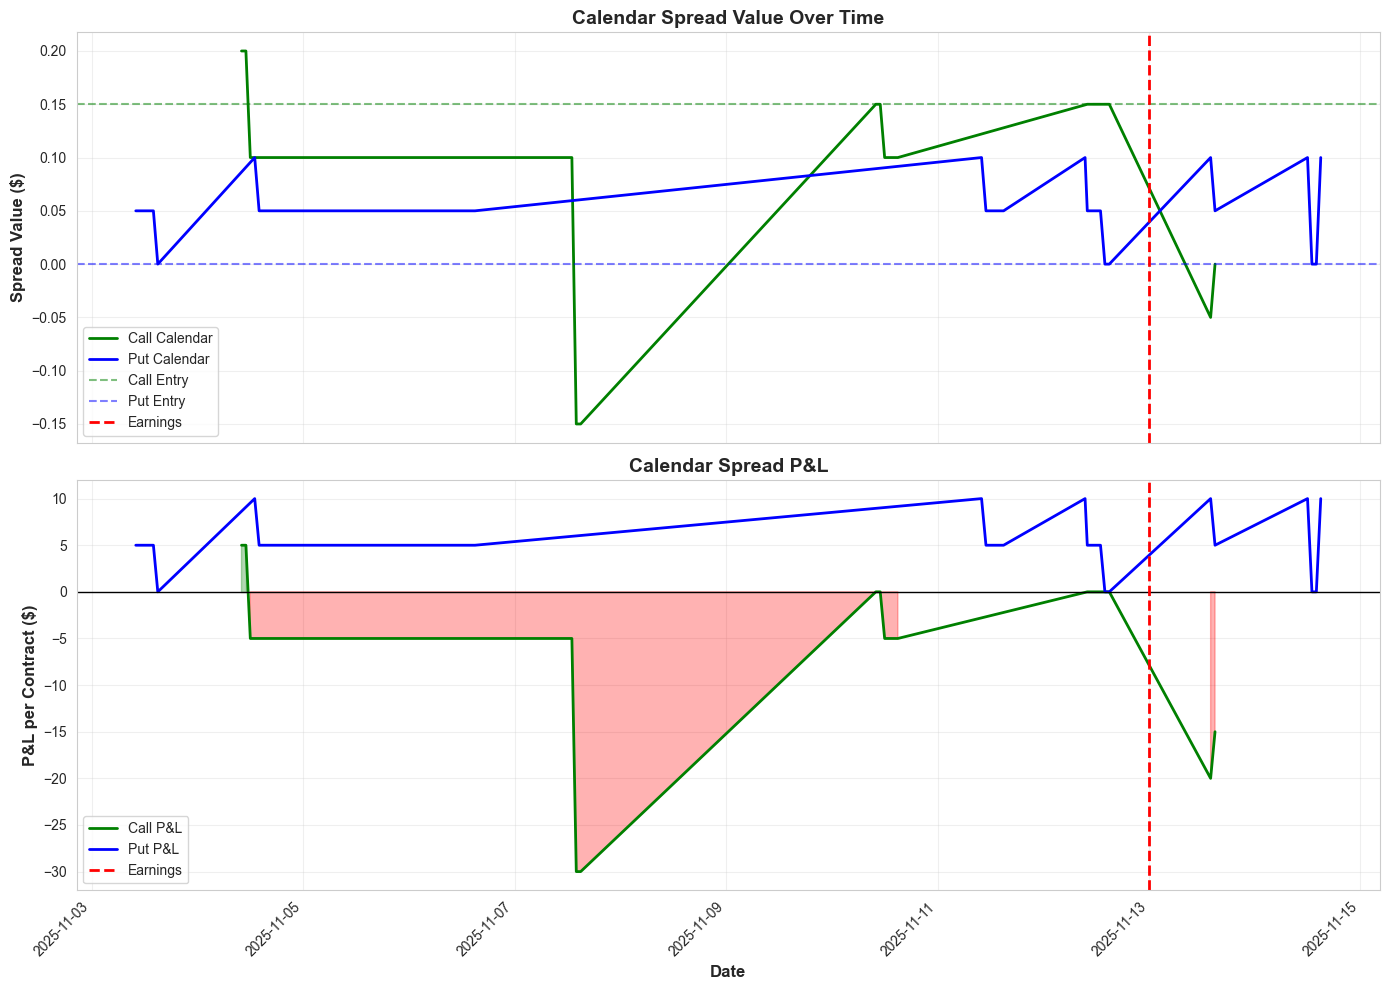


📊 Notice how P&L changes around earnings due to IV crush


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Spread Value
ax1 = axes[0]
ax1.plot(call_pnl['datetime'], call_pnl['spread_value'], label='Call Calendar', linewidth=2, color='green')
ax1.plot(put_pnl['datetime'], put_pnl['spread_value'], label='Put Calendar', linewidth=2, color='blue')
ax1.axhline(y=call_spread_cost, color='green', linestyle='--', alpha=0.5, label='Call Entry')
ax1.axhline(y=put_spread_cost, color='blue', linestyle='--', alpha=0.5, label='Put Entry')
ax1.axvline(x=pd.to_datetime(earnings_date), color='red', linestyle='--', linewidth=2, label='Earnings')
ax1.set_ylabel('Spread Value ($)', fontsize=12, fontweight='bold')
ax1.set_title('Calendar Spread Value Over Time', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: P&L
ax2 = axes[1]
ax2.plot(call_pnl['datetime'], call_pnl['pnl_per_contract'], label='Call P&L', linewidth=2, color='green')
ax2.plot(put_pnl['datetime'], put_pnl['pnl_per_contract'], label='Put P&L', linewidth=2, color='blue')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=pd.to_datetime(earnings_date), color='red', linestyle='--', linewidth=2, label='Earnings')
ax2.fill_between(call_pnl['datetime'], 0, call_pnl['pnl_per_contract'], 
                  where=(call_pnl['pnl_per_contract'] >= 0), alpha=0.3, color='green')
ax2.fill_between(call_pnl['datetime'], 0, call_pnl['pnl_per_contract'], 
                  where=(call_pnl['pnl_per_contract'] < 0), alpha=0.3, color='red')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('P&L per Contract ($)', fontsize=12, fontweight='bold')
ax2.set_title('Calendar Spread P&L', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Notice how P&L changes around earnings due to IV crush")

## 5. Exit Timing Analysis
**Key Question**: Should we exit **before** or **after** earnings?

This depends on earnings timing (pre-market vs after-hours)

In [12]:
# Check TMC earnings timing using EarningsCalendarReader
earnings_reader = EarningsCalendarReader(database_path='../data', dataset_name='earnings')

earnings_info = earnings_reader.get_earnings_for_symbol(
    symbol='TMC',
    start_date=date(2025, 11, 1),
    end_date=date(2025, 11, 30)
)

print("TMC Earnings Info:")
print(earnings_info[['symbol', 'earnings_date', 'earnings_time', 'company_name']])

if earnings_info.empty:
    print("\n⚠️ No earnings data found for TMC in November 2025")
    earnings_time = 'AFTER_HOURS'  # Default assumption
else:
    earnings_time = earnings_info['earnings_time'].iloc[0]

print(f"\n⏰ Earnings Time: {earnings_time}")
print(f"\nImplication:")
if earnings_time == 'AFTER_HOURS':
    print("  • Exit on Nov 13 close = BEFORE earnings (IV still high)")
    print("  • Exit on Nov 14 = AFTER earnings (IV crush captured)")
    print("  → Best to exit on Nov 14 to capture IV crush")
else:
    print("  • Exit on Nov 13 open = BEFORE earnings (IV still high)")
    print("  • Exit on Nov 13 close = AFTER earnings (IV crush captured)")
    print("  → Best to exit on Nov 13 close to capture IV crush")

TMC Earnings Info:
  symbol earnings_date earnings_time                 company_name
0    TMC    2025-11-13   AFTER_HOURS  TMC the metals company Inc.

⏰ Earnings Time: AFTER_HOURS

Implication:
  • Exit on Nov 13 close = BEFORE earnings (IV still high)
  • Exit on Nov 14 = AFTER earnings (IV crush captured)
  → Best to exit on Nov 14 to capture IV crush


In [13]:
# Compare exit scenarios using specific datetimes
def calculate_exit_pnl_at_time(pnl_df, exit_dt, entry_cost):
    """Calculate P&L at specific exit datetime"""
    # Find most recent bar at or before exit time
    exit_bars = pnl_df[pnl_df['datetime'] <= exit_dt]
    if len(exit_bars) == 0:
        return None
    
    exit_row = exit_bars.iloc[-1]
    pnl = exit_row['pnl']
    pnl_per_contract = pnl * 100
    
    # Handle division by zero for pct
    if entry_cost > 0.001:  # Avoid near-zero
        pnl_pct = (pnl / entry_cost) * 100
    else:
        pnl_pct = float('inf') if pnl > 0 else 0
    
    return {
        'pnl': pnl,
        'pnl_per_contract': pnl_per_contract,
        'pnl_pct': pnl_pct,
        'spread_value': exit_row['spread_value'],
        'datetime': exit_row['datetime']
    }

# Exit scenarios with specific times (AFTER_HOURS earnings)
exit_before = datetime(2025, 11, 13, 16, 0, 0)  # Market close before earnings
exit_after = datetime(2025, 11, 14, 10, 0, 0)   # 10am after IV crush

# Calculate for both spreads
call_exit_before = calculate_exit_pnl_at_time(call_pnl, exit_before, call_spread_cost)
call_exit_after = calculate_exit_pnl_at_time(call_pnl, exit_after, call_spread_cost)

put_exit_before = calculate_exit_pnl_at_time(put_pnl, exit_before, put_spread_cost)
put_exit_after = calculate_exit_pnl_at_time(put_pnl, exit_after, put_spread_cost)

print("="*80)
print("EXIT TIMING COMPARISON")
print("="*80)

print(f"\n📅 CALL CALENDAR SPREAD (entry cost: ${call_spread_cost*100:.2f})")
print(f"\n  Exit BEFORE Earnings ({exit_before}):")
print(f"    Spread Value: ${call_exit_before['spread_value']:.3f}")
print(f"    P&L: ${call_exit_before['pnl_per_contract']:.2f} ({call_exit_before['pnl_pct']:.1f}%)")
print(f"\n  Exit AFTER Earnings ({exit_after}):")
print(f"    Spread Value: ${call_exit_after['spread_value']:.3f}")
print(f"    P&L: ${call_exit_after['pnl_per_contract']:.2f} ({call_exit_after['pnl_pct']:.1f}%)")
print(f"\n  Difference: ${(call_exit_after['pnl_per_contract'] - call_exit_before['pnl_per_contract']):.2f}")
print(f"  → {'WAIT for IV crush' if call_exit_after['pnl_per_contract'] > call_exit_before['pnl_per_contract'] else 'EXIT before earnings'}")

# Only show put calendar if entry cost > 0
if put_spread_cost > 0.001:
    print(f"\n📅 PUT CALENDAR SPREAD (entry cost: ${put_spread_cost*100:.2f})")
    print(f"\n  Exit BEFORE Earnings ({exit_before}):")
    print(f"    Spread Value: ${put_exit_before['spread_value']:.3f}")
    print(f"    P&L: ${put_exit_before['pnl_per_contract']:.2f}")
    print(f"\n  Exit AFTER Earnings ({exit_after}):")
    print(f"    Spread Value: ${put_exit_after['spread_value']:.3f}")
    print(f"    P&L: ${put_exit_after['pnl_per_contract']:.2f}")
    print(f"\n  Difference: ${(put_exit_after['pnl_per_contract'] - put_exit_before['pnl_per_contract']):.2f}")
else:
    print(f"\n📅 PUT CALENDAR SPREAD")
    print(f"  Entry cost: ~$0 (both legs priced equally)")
    print(f"  → Skip this spread (no edge, too cheap to trade profitably)")

print(f"\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
if earnings_time == 'AFTER_HOURS':
    print(f"\n✅ Since earnings are AFTER_HOURS on {earnings_date}:")
    print(f"   1. IV crush happens overnight (Nov 13 → Nov 14)")
    print(f"   2. Short-term options lose more value than long-term")
    print(f"   3. Calendar spread benefits from this differential")
    print(f"\n💡 OPTIMAL EXIT: Nov 14 10am (capture full IV crush)")
    print(f"   Expected improvement: ${(call_exit_after['pnl_per_contract'] - call_exit_before['pnl_per_contract']):.2f} per contract")
else:
    print(f"\n✅ Since earnings are PRE_MARKET on {earnings_date}:")
    print(f"   1. IV crush happens at market open")
    print(f"   2. Exit during Nov 13 trading day to capture crush")
    print(f"\n💡 OPTIMAL EXIT: Nov 13 4pm (capture IV crush same day)")

print(f"\n⚠️  Risk Management:")
print(f"   • Set target profit (e.g., 50-100% of max gain)")
print(f"   • Consider early exit if big move away from strike")
print(f"   • Avoid holding through short leg expiration (assignment risk)")

EXIT TIMING COMPARISON

📅 CALL CALENDAR SPREAD (entry cost: $15.00)

  Exit BEFORE Earnings (2025-11-13 16:00:00):
    Spread Value: $0.000
    P&L: $-15.00 (-100.0%)

  Exit AFTER Earnings (2025-11-14 10:00:00):
    Spread Value: $0.000
    P&L: $-15.00 (-100.0%)

  Difference: $0.00
  → EXIT before earnings

📅 PUT CALENDAR SPREAD
  Entry cost: ~$0 (both legs priced equally)
  → Skip this spread (no edge, too cheap to trade profitably)

RECOMMENDATION

✅ Since earnings are AFTER_HOURS on 2025-11-13:
   1. IV crush happens overnight (Nov 13 → Nov 14)
   2. Short-term options lose more value than long-term
   3. Calendar spread benefits from this differential

💡 OPTIMAL EXIT: Nov 14 10am (capture full IV crush)
   Expected improvement: $0.00 per contract

⚠️  Risk Management:
   • Set target profit (e.g., 50-100% of max gain)
   • Consider early exit if big move away from strike
   • Avoid holding through short leg expiration (assignment risk)


## 6. Strategy Summary

In [14]:
call_final = call_pnl.iloc[-1]
put_final = put_pnl.iloc[-1]

print("="*80)
print("CALENDAR SPREAD SUMMARY: TMC EARNINGS")
print("="*80)

print(f"\nSETUP:")
print(f"  Underlying: TMC")
print(f"  Earnings: {earnings_date}")
print(f"  Entry: {entry_dt.date()}")
print(f"  Strike: ${strike}")
print(f"  Short Leg: {short_exp}")
print(f"  Long Leg: {long_exp}")

print(f"\nCOSTS:")
print(f"  Call Spread: ${call_spread_cost * 100:.2f}/contract (max loss)")
print(f"  Put Spread: ${put_spread_cost * 100:.2f}/contract (max loss)")

print(f"\nFINAL PERFORMANCE (as of {call_final['datetime'].date()}):")
print(f"  Call P&L: ${call_final['pnl_per_contract']:.2f} ({call_final['pnl_pct']:.1f}%)")
print(f"  Put P&L: ${put_final['pnl_per_contract']:.2f} ({put_final['pnl_pct']:.1f}%)")

print(f"\nSTRATEGY ADVANTAGES:")
print("  ✓ Limited risk (max loss = net debit)")
print("  ✓ Profits from IV crush after earnings")
print("  ✓ Delta-neutral (minimal directional exposure)")
print("  ✓ Benefits from time decay differential")

print(f"\nKEY INSIGHTS:")
print("  • Calendar spreads are VOLATILITY plays, not directional")
print("  • Maximum profit when spot price stays near strike")
print("  • IV differential (short vs long) is critical")
print("  • Best used before high IV events (earnings, Fed meetings)")

print("="*80)

CALENDAR SPREAD SUMMARY: TMC EARNINGS

SETUP:
  Underlying: TMC
  Earnings: 2025-11-13
  Entry: 2025-11-12
  Strike: $5.0
  Short Leg: 2025-11-21
  Long Leg: 2025-11-28

COSTS:
  Call Spread: $15.00/contract (max loss)
  Put Spread: $0.00/contract (max loss)

FINAL PERFORMANCE (as of 2025-11-13):
  Call P&L: $-15.00 (-100.0%)
  Put P&L: $10.00 (inf%)

STRATEGY ADVANTAGES:
  ✓ Limited risk (max loss = net debit)
  ✓ Profits from IV crush after earnings
  ✓ Delta-neutral (minimal directional exposure)
  ✓ Benefits from time decay differential

KEY INSIGHTS:
  • Calendar spreads are VOLATILITY plays, not directional
  • Maximum profit when spot price stays near strike
  • IV differential (short vs long) is critical
  • Best used before high IV events (earnings, Fed meetings)
